
# Assignment 3 — From Raw Signals to a Lean Feature Set

**Course:** Feature Engineering & MLOps  
**Topic:**  Time-based Features, Feature Creation, and Feature Selection

**Dataset:** `daily_batch_performance.csv`  
**Target:** `new_enrollments`


## 1. Imports and Configuration

In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

RANDOM_STATE = 42
DATA_PATH = "daily_batch_performance.csv"

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 2. Data Loading and Initial Inspection

In [2]:

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
display(df.head())


Shape: (730, 10)

Columns:
['date', 'marketing_spend', 'discount_pct', 'website_visits', 'website_visits_copy', 'competitor_promo_flag', 'is_holiday', 'random_noise_1', 'random_noise_2', 'new_enrollments']

Data types:
date                     datetime64[ns]
marketing_spend                 float64
discount_pct                      int64
website_visits                  float64
website_visits_copy             float64
competitor_promo_flag             int64
is_holiday                        int64
random_noise_1                  float64
random_noise_2                   object
new_enrollments                   int64
dtype: object

First 5 rows:


,date,marketing_spend,discount_pct,website_visits,website_visits_copy,competitor_promo_flag,is_holiday,random_noise_1,random_noise_2,new_enrollments
0,2024-01-01,"9,069.0000",10,561.0000,567.0000,1,1,60.6000,A,20
1,2024-01-02,"6,573.0000",10,559.0000,570.0000,1,1,82.9000,C,23
2,2024-01-03,"14,636.0000",0,539.0000,554.0000,0,0,41.9000,A,29
3,2024-01-04,"3,979.0000",5,574.0000,557.0000,0,0,44.4000,B,30
4,2024-01-05,"9,654.0000",10,661.0000,661.0000,0,0,23.8000,B,38


In [3]:

print("Missing values:")
display(df.isna().sum().to_frame("missing_values"))

print("Duplicate rows:", df.duplicated().sum())

print("\nSummary statistics:")
display(df.describe(include="all").transpose())

print("\nUnique values:")
display(df.nunique().to_frame("unique_values"))

constant_columns = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print("Constant columns:", constant_columns if constant_columns else "None")


Missing values:


,missing_values
date,0
marketing_spend,0
discount_pct,0
website_visits,0
website_visits_copy,0
competitor_promo_flag,0
is_holiday,0
random_noise_1,0
random_noise_2,0
new_enrollments,0


Duplicate rows: 0

Summary statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,730,NaN,NaN,NaN,2024-12-30 12:00:00,2024-01-01 00:00:00,2024-07-01 06:00:00,2024-12-30 12:00:00,2025-06-30 18:00:00,2025-12-30 00:00:00,NaN
marketing_spend,730.0000,NaN,NaN,NaN,"7,989.4836",500.0000,"6,361.7500","8,037.5000","9,763.0000","17,161.0000","2,525.1461"
discount_pct,730.0000,NaN,NaN,NaN,7.3151,0.0000,0.0000,5.0000,15.0000,20.0000,7.4432
website_visits,730.0000,NaN,NaN,NaN,558.0493,263.0000,505.0000,556.5000,617.0000,798.0000,78.6813
website_visits_copy,730.0000,NaN,NaN,NaN,557.9233,268.0000,506.0000,557.0000,616.0000,790.0000,78.9057
competitor_promo_flag,730.0000,NaN,NaN,NaN,0.1466,0.0000,0.0000,0.0000,0.0000,1.0000,0.3539
is_holiday,730.0000,NaN,NaN,NaN,0.0370,0.0000,0.0000,0.0000,0.0000,1.0000,0.1889
random_noise_1,730.0000,NaN,NaN,NaN,49.4851,7.6000,41.4250,50.0500,57.2000,88.9000,12.3372
random_noise_2,730,3,A,257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
new_enrollments,730.0000,NaN,NaN,NaN,46.0411,17.0000,40.0000,46.0000,52.0000,77.0000,9.1580



Unique values:


,unique_values
date,730
marketing_spend,694
discount_pct,5
website_visits,281
website_visits_copy,286
competitor_promo_flag,2
is_holiday,2
random_noise_1,377
random_noise_2,3
new_enrollments,53


Constant columns: None


## 4.1 — Phase 3: Time-based Features & Feature Creation

### 4.1.1 — Enrollment Trend Over Time

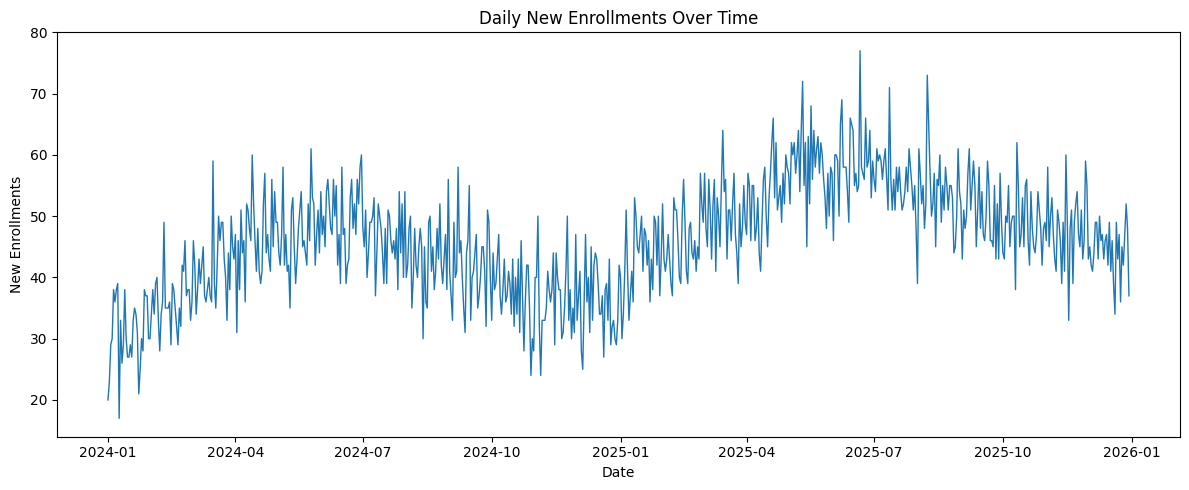

By-eye observation: the series shows an overall time trend with recurring short-term fluctuations; the plot should be used to inspect any visible weekly rhythm or changing variability.


In [4]:

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["new_enrollments"], linewidth=1)
plt.title("Daily New Enrollments Over Time")
plt.xlabel("Date")
plt.ylabel("New Enrollments")
plt.tight_layout()
plt.show()

print("By-eye observation: the series shows an overall time trend with recurring short-term fluctuations; the plot should be used to inspect any visible weekly rhythm or changing variability.")


### 4.1.2 — Lag Features and Correlations

In [5]:

df["marketing_spend_lag1"] = df["marketing_spend"].shift(1)
df["marketing_spend_lag2"] = df["marketing_spend"].shift(2)

corrs = pd.Series({
    "marketing_spend": df["marketing_spend"].corr(df["new_enrollments"]),
    "marketing_spend_lag1": df["marketing_spend_lag1"].corr(df["new_enrollments"]),
    "marketing_spend_lag2": df["marketing_spend_lag2"].corr(df["new_enrollments"])
}).sort_values(ascending=False)

display(corrs.to_frame("correlation_with_new_enrollments"))

strongest = corrs.abs().idxmax()
print(f"Strongest absolute correlation: {strongest} ({corrs[strongest]:.4f}).")
print("A lagged marketing-spend measure can be more predictive because advertising exposure may take time to turn into inquiries, visits, and eventual enrollments.")


,correlation_with_new_enrollments
marketing_spend_lag2,0.2184
marketing_spend,0.1189
marketing_spend_lag1,-0.0092


Strongest absolute correlation: marketing_spend_lag2 (0.2184).
A lagged marketing-spend measure can be more predictive because advertising exposure may take time to turn into inquiries, visits, and eventual enrollments.


### Lag Feature Correlation Analysis

Among the three marketing spend features, marketing_spend_lag2 has the strongest correlation with new_enrollments (0.2184), compared with same-day marketing_spend (0.1189) and marketing_spend_lag1 (-0.0092). This shows that the marketing spend from two days earlier has a stronger relationship with current enrollments than same-day spending. This makes real-world sense for a coaching institute because students usually do not see an advertisement and enroll immediately; it can take time for them to notice the advertisement, visit the institute or website, gather information, and finally convert into a walk-in or enrollment.

### 4.1.3 — 7-Day Rolling Features

In [6]:

df["enrollments_rolling_mean_7d"] = df["new_enrollments"].rolling(window=7).mean()
df["enrollments_rolling_std_7d"] = df["new_enrollments"].rolling(window=7).std()

display(df[["date", "new_enrollments", "enrollments_rolling_mean_7d",
            "enrollments_rolling_std_7d"]].head(10))


,date,new_enrollments,enrollments_rolling_mean_7d,enrollments_rolling_std_7d
0,2024-01-01,20,NaN,NaN
1,2024-01-02,23,NaN,NaN
2,2024-01-03,29,NaN,NaN
3,2024-01-04,30,NaN,NaN
4,2024-01-05,38,NaN,NaN
5,2024-01-06,36,NaN,NaN
6,2024-01-07,38,30.5714,7.2078
7,2024-01-08,39,33.2857,6.0474
8,2024-01-09,17,32.4286,7.8921
9,2024-01-10,33,33.0000,7.7460


### 4.1.4 — Cyclical Day-of-Week Encoding

In [7]:

df["day_of_week"] = df["date"].dt.dayofweek
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

display(df[["date", "day_of_week", "dow_sin", "dow_cos"]].head(10))

print("A plain 0–6 encoding incorrectly treats Sunday and Monday as far apart, even though they are adjacent in the weekly cycle; sine/cosine preserves that cyclic relationship.")


,date,day_of_week,dow_sin,dow_cos
0,2024-01-01,0,0.0000,1.0000
1,2024-01-02,1,0.7818,0.6235
2,2024-01-03,2,0.9749,-0.2225
3,2024-01-04,3,0.4339,-0.9010
4,2024-01-05,4,-0.4339,-0.9010
5,2024-01-06,5,-0.9749,-0.2225
6,2024-01-07,6,-0.7818,0.6235
7,2024-01-08,0,0.0000,1.0000
8,2024-01-09,1,0.7818,0.6235
9,2024-01-10,2,0.9749,-0.2225


A plain 0–6 encoding incorrectly treats Sunday and Monday as far apart, even though they are adjacent in the weekly cycle; sine/cosine preserves that cyclic relationship.


### 4.1.5 — Trend Feature

In [8]:

df["time_index"] = np.arange(len(df))

trend_model = LinearRegression()
trend_model.fit(df[["time_index"]], df["new_enrollments"])

daily_growth = trend_model.coef_[0]
trend_r2 = trend_model.score(df[["time_index"]], df["new_enrollments"])

print(f"Estimated daily growth in enrollments: {daily_growth:.4f} enrollments/day")
print(f"R² of target ~ time_index: {trend_r2:.4f}")


Estimated daily growth in enrollments: 0.0202 enrollments/day
R² of target ~ time_index: 0.2158


### 4.1.6 — Interaction Feature and Test R² Comparison

In [9]:

df["spend_x_discount"] = df["marketing_spend_lag2"] * df["discount_pct"]

interaction_features = [
    "marketing_spend_lag1", "marketing_spend_lag2",
    "discount_pct", "website_visits", "competitor_promo_flag",
    "is_holiday", "dow_sin", "dow_cos", "time_index"
]
with_interaction = interaction_features + ["spend_x_discount"]

model_df = df.dropna(subset=with_interaction + ["new_enrollments"]).copy()
X = model_df[interaction_features]
X_int = model_df[with_interaction]
y = model_df["new_enrollments"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_int, y, test_size=0.20, random_state=RANDOM_STATE
)

base_model = LinearRegression().fit(X_train, y_train)
interaction_model = LinearRegression().fit(Xi_train, yi_train)

base_r2 = r2_score(y_test, base_model.predict(X_test))
interaction_r2 = r2_score(yi_test, interaction_model.predict(Xi_test))

interaction_results = pd.DataFrame({
    "model": ["Without interaction", "With interaction"],
    "test_R2": [base_r2, interaction_r2]
})
display(interaction_results)

gain = interaction_r2 - base_r2
print(f"Test R² change from adding interaction: {gain:+.4f}")
print("Conclusion:", "The interaction helps." if gain > 0 else "The interaction does not improve test R² on this split.")


,model,test_R2
0,Without interaction,0.3950
1,With interaction,0.3897


Test R² change from adding interaction: -0.0053
Conclusion: The interaction does not improve test R² on this split.


### 4.1.7 — Remove Leading NaN Rows

In [10]:

rows_before = len(df)

# Lag features require previous days; rolling features require a complete 7-day window.
# These are structurally unavailable observations, not ordinary missing measurements.
df_model = df.dropna().reset_index(drop=True)

print(f"Rows before dropping leading NaNs: {rows_before}")
print(f"Rows after dropping leading NaNs:  {len(df_model)}")
print("The leading rows cannot be meaningfully mean/median-imputed because their lag/rolling values do not exist yet in the time series; imputing them would fabricate historical information.")


Rows before dropping leading NaNs: 730
Rows after dropping leading NaNs:  724
The leading rows cannot be meaningfully mean/median-imputed because their lag/rolling values do not exist yet in the time series; imputing them would fabricate historical information.


## 4.2 — Phase 4: Feature Selection

### Candidate Feature Set

In [11]:

target = "new_enrollments"
candidate_features = [
    "marketing_spend",
    "discount_pct",
    "website_visits",
    "website_visits_copy",
    "competitor_promo_flag",
    "is_holiday",
    "random_noise_1",
    "random_noise_2",
    "marketing_spend_lag1",
    "marketing_spend_lag2",
    "enrollments_rolling_mean_7d",
    "enrollments_rolling_std_7d",
    "dow_sin",
    "dow_cos",
    "time_index",
    "spend_x_discount"
]

print("Candidate features:")
print(candidate_features)


Candidate features:
['marketing_spend', 'discount_pct', 'website_visits', 'website_visits_copy', 'competitor_promo_flag', 'is_holiday', 'random_noise_1', 'random_noise_2', 'marketing_spend_lag1', 'marketing_spend_lag2', 'enrollments_rolling_mean_7d', 'enrollments_rolling_std_7d', 'dow_sin', 'dow_cos', 'time_index', 'spend_x_discount']


### 4.2.1 — Variance Threshold

In [12]:

numeric_candidates = df_model[candidate_features].select_dtypes(include=np.number).columns.tolist()
X_numeric = df_model[numeric_candidates]

variances = X_numeric.var().sort_values()
display(variances.to_frame("variance"))

threshold = 1e-8
vt = VarianceThreshold(threshold=threshold)
vt.fit(X_numeric)

variance_kept = X_numeric.columns[vt.get_support()].tolist()
variance_dropped = [c for c in X_numeric.columns if c not in variance_kept]

print("Near-constant features dropped:", variance_dropped if variance_dropped else "None")
print("Conclusion: no feature is forcibly removed unless its variance is actually at/below the chosen near-constant threshold.")


,variance
is_holiday,0.0334
competitor_promo_flag,0.1242
dow_sin,0.5003
dow_cos,0.5011
enrollments_rolling_std_7d,2.2036
enrollments_rolling_mean_7d,54.8838
discount_pct,55.6680
random_noise_1,150.6816
website_visits,"6,226.4705"
website_visits_copy,"6,262.6660"


Near-constant features dropped: None
Conclusion: no feature is forcibly removed unless its variance is actually at/below the chosen near-constant threshold.


### 4.2.2 — Correlation Filtering

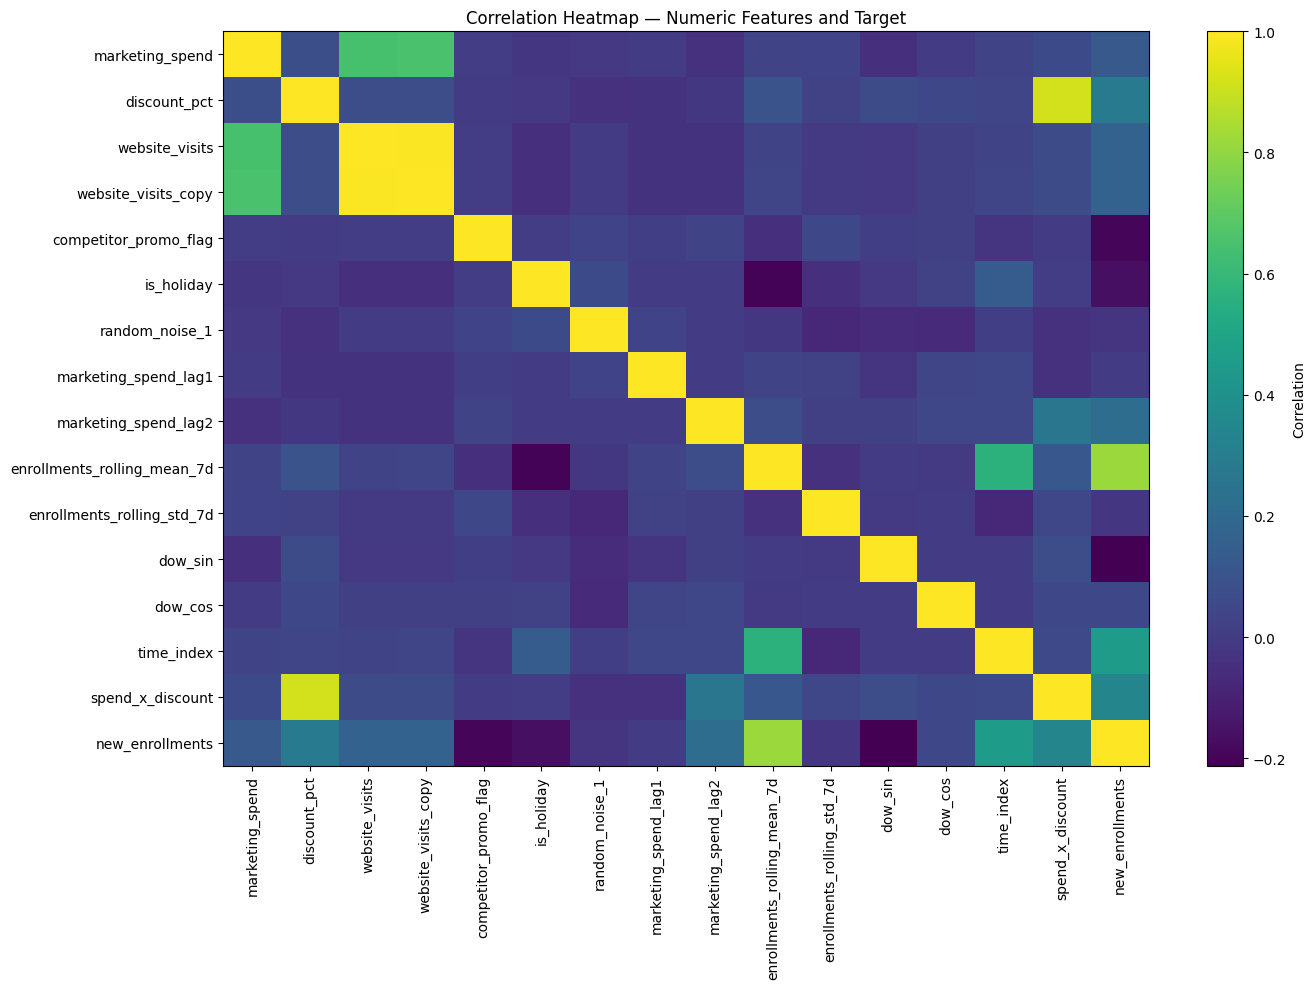

Correlation between website_visits and website_visits_copy: 0.9947

Highly correlated feature pairs (|r| >= 0.95):


,feature_1,feature_2,correlation
0,website_visits,website_visits_copy,0.9947


Decision: drop website_visits_copy because it is the planted near-duplicate; retain website_visits as the original feature.


In [13]:

corr = df_model[numeric_candidates + [target]].corr()

plt.figure(figsize=(14, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap — Numeric Features and Target")
plt.tight_layout()
plt.show()

pair_corr = df_model["website_visits"].corr(df_model["website_visits_copy"])
print(f"Correlation between website_visits and website_visits_copy: {pair_corr:.4f}")

corr_threshold = 0.95
high_corr_pairs = []
cols = numeric_candidates
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        value = corr.loc[cols[i], cols[j]]
        if abs(value) >= corr_threshold:
            high_corr_pairs.append((cols[i], cols[j], value))

print("\nHighly correlated feature pairs (|r| >= 0.95):")
display(pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "correlation"])
        if high_corr_pairs else pd.DataFrame(columns=["feature_1", "feature_2", "correlation"]))

# The planted near-duplicate is intentionally removed from the candidate set for the
# correlation-filtered version, while all other features remain.
correlation_dropped = ["website_visits_copy"]
correlation_kept = [c for c in numeric_candidates if c not in correlation_dropped]

print("Decision: drop website_visits_copy because it is the planted near-duplicate; retain website_visits as the original feature.")


### 4.2.3 — Mutual Information

In [14]:

mi = mutual_info_regression(
    df_model[numeric_candidates],
    df_model[target],
    random_state=RANDOM_STATE
)

mi_table = pd.DataFrame({
    "feature": numeric_candidates,
    "mutual_information": mi
}).sort_values("mutual_information", ascending=False).reset_index(drop=True)

display(mi_table)

noise_mi = mi_table[mi_table["feature"].isin(["random_noise_1"])]
print("random_noise_1 rank:", int(noise_mi.index[0] + 1) if len(noise_mi) else "not found")
print("random_noise_2 is categorical and therefore is not included in this numeric-feature MI ranking.")


,feature,mutual_information
0,enrollments_rolling_mean_7d,0.5479
1,time_index,0.4900
2,spend_x_discount,0.0848
3,discount_pct,0.0511
4,competitor_promo_flag,0.0491
5,dow_sin,0.0342
6,enrollments_rolling_std_7d,0.0165
7,is_holiday,0.0081
8,random_noise_1,0.0053
9,website_visits,0.0041


random_noise_1 rank: 9
random_noise_2 is categorical and therefore is not included in this numeric-feature MI ranking.



### 4.2.4 — Trick Question: Chi-Square and ANOVA F-Test

Neither chi-square nor the ANOVA F-test is the right tool here because the target, new_enrollments, is a continuous numeric variable. Chi-square is used to test relationships involving categorical variables and frequency counts, while the classification-oriented ANOVA F-test used in feature selection expects a categorical target with discrete groups/classes. Therefore, regression-based methods such as correlation or mutual_info_regression are more appropriate for filtering features against new_enrollments.


### 4.2.5 — RFE with Linear Regression: Top 6

In [15]:

X_rfe = df_model[numeric_candidates]
y_rfe = df_model[target]

rfe = RFE(
    estimator=LinearRegression(),
    n_features_to_select=6,
    step=1
)
rfe.fit(X_rfe, y_rfe)

rfe_table = pd.DataFrame({
    "feature": numeric_candidates,
    "rfe_ranking": rfe.ranking_,
    "rfe_kept": np.where(rfe.support_, "kept", "dropped")
}).sort_values(["rfe_ranking", "feature"])

display(rfe_table)
print("Top 6 RFE features:", rfe_table.loc[rfe_table["rfe_kept"] == "kept", "feature"].tolist())


,feature,rfe_ranking,rfe_kept
4,competitor_promo_flag,1,kept
1,discount_pct,1,kept
12,dow_cos,1,kept
11,dow_sin,1,kept
9,enrollments_rolling_mean_7d,1,kept
5,is_holiday,1,kept
10,enrollments_rolling_std_7d,2,dropped
2,website_visits,3,dropped
6,random_noise_1,4,dropped
3,website_visits_copy,5,dropped


Top 6 RFE features: ['competitor_promo_flag', 'discount_pct', 'dow_cos', 'dow_sin', 'enrollments_rolling_mean_7d', 'is_holiday']


### 4.2.6 — Embedded Method: Standardized LassoCV

In [16]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model[numeric_candidates])

lasso = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=100000)
lasso.fit(X_scaled, y_rfe)

lasso_table = pd.DataFrame({
    "feature": numeric_candidates,
    "lasso_coefficient": lasso.coef_
})
lasso_table["lasso_abs_coefficient"] = lasso_table["lasso_coefficient"].abs()
lasso_table["lasso_status"] = np.where(
    lasso_table["lasso_abs_coefficient"] <= 1e-4, "dropped", "kept"
)
lasso_table = lasso_table.sort_values("lasso_abs_coefficient", ascending=False)

display(lasso_table)
print(f"Selected alpha: {lasso.alpha_:.6f}")
print("Zero/nearly-zero Lasso features:",
      lasso_table.loc[lasso_table["lasso_status"] == "dropped", "feature"].tolist())


,feature,lasso_coefficient,lasso_abs_coefficient,lasso_status
9,enrollments_rolling_mean_7d,6.9031,6.9031,kept
11,dow_sin,-1.9895,1.9895,kept
1,discount_pct,1.5197,1.5197,kept
8,marketing_spend_lag2,1.4347,1.4347,kept
4,competitor_promo_flag,-1.4104,1.4104,kept
2,website_visits,1.0744,1.0744,kept
14,spend_x_discount,0.4710,0.4710,kept
12,dow_cos,0.2865,0.2865,kept
7,marketing_spend_lag1,-0.1440,0.1440,kept
6,random_noise_1,-0.0688,0.0688,kept


Selected alpha: 0.064227
Zero/nearly-zero Lasso features: ['is_holiday', 'website_visits_copy', 'marketing_spend', 'time_index']


### 4.2.7 — Filter vs Wrapper vs Embedded Comparison

In [17]:

# Filter comparison combines the requested filter families:
# variance threshold, correlation filtering, and MI ranking.
# For a single kept/dropped column in the comparison table, MI is treated as informative if it is above zero, while variance/correlation explicitly remove only features justified by their respective rules.

mi_kept = set(mi_table.loc[mi_table["mutual_information"] > 0, "feature"])

comparison = pd.DataFrame({"feature": numeric_candidates})
comparison["variance_threshold"] = comparison["feature"].map(
    lambda x: "kept" if x in variance_kept else "dropped"
)
comparison["correlation_filter"] = comparison["feature"].map(
    lambda x: "kept" if x in correlation_kept else "dropped"
)
comparison["mutual_information"] = comparison["feature"].map(
    lambda x: "kept" if x in mi_kept else "dropped"
)
comparison["filter"] = np.where(
    (comparison["variance_threshold"] == "dropped") |
    (comparison["correlation_filter"] == "dropped") |
    (comparison["mutual_information"] == "dropped"),
    "dropped",
    "kept"
)
comparison["wrapper_RFE"] = comparison["feature"].map(
    dict(zip(rfe_table["feature"], rfe_table["rfe_kept"]))
)
comparison["embedded_Lasso"] = comparison["feature"].map(
    dict(zip(lasso_table["feature"], lasso_table["lasso_status"]))
)

display(comparison)

print("\nNoise-column summary:")
display(comparison[comparison["feature"].isin(["random_noise_1", "random_noise_2"])])

print("\nWebsite duplicate summary:")
display(comparison[comparison["feature"].isin(["website_visits", "website_visits_copy"])])


,feature,variance_threshold,correlation_filter,mutual_information,filter,wrapper_RFE,embedded_Lasso
0,marketing_spend,kept,kept,kept,kept,dropped,dropped
1,discount_pct,kept,kept,kept,kept,kept,kept
2,website_visits,kept,kept,kept,kept,dropped,kept
3,website_visits_copy,kept,dropped,dropped,dropped,dropped,dropped
4,competitor_promo_flag,kept,kept,kept,kept,kept,kept
5,is_holiday,kept,kept,kept,kept,kept,dropped
6,random_noise_1,kept,kept,kept,kept,dropped,kept
7,marketing_spend_lag1,kept,kept,dropped,dropped,dropped,kept
8,marketing_spend_lag2,kept,kept,dropped,dropped,dropped,kept
9,enrollments_rolling_mean_7d,kept,kept,kept,kept,kept,kept



Noise-column summary:


,feature,variance_threshold,correlation_filter,mutual_information,filter,wrapper_RFE,embedded_Lasso
6,random_noise_1,kept,kept,kept,kept,dropped,kept



Website duplicate summary:


,feature,variance_threshold,correlation_filter,mutual_information,filter,wrapper_RFE,embedded_Lasso
2,website_visits,kept,kept,kept,kept,dropped,kept
3,website_visits_copy,kept,dropped,dropped,dropped,dropped,dropped


random_noise_2 is categorical (A/B/C) and is intentionally excluded from the numeric-only correlation, variance, mutual_info_regression, RFE, and Lasso matrices used in the current analysis. For inclusion in a modeling pipeline, it would first need to be encoded into a numerical representation before these numerical feature-selection methods could be applied.

The two noise columns do not get dropped by all three approaches. random_noise_1 is kept by the Filter approach and Lasso but dropped by RFE. Since random_noise_2 is categorical and not included in the numeric-feature comparison table, we cannot conclude from this analysis that it was dropped by all three approaches.

In contrast, website_visits_copy is caught by all three main approaches. The Filter approach drops it because the correlation filter identifies it as redundant with website_visits; RFE drops it because it is not selected among the most useful features; and Lasso drops it by shrinking its coefficient to zero or a negligible value. Therefore, the redundant copy is consistently identified as unnecessary, while the noise features are not consistently removed by every method.

## Bonus — Random Forest Embedded Importance

In [18]:

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(df_model[numeric_candidates], y_rfe)

rf_importance = pd.DataFrame({
    "feature": numeric_candidates,
    "random_forest_importance": rf.feature_importances_
}).sort_values("random_forest_importance", ascending=False)

display(rf_importance)

duplicate_rf = rf_importance[rf_importance["feature"].isin(
    ["website_visits", "website_visits_copy"]
)]
display(duplicate_rf)


,feature,random_forest_importance
9,enrollments_rolling_mean_7d,0.6871
14,spend_x_discount,0.0784
11,dow_sin,0.0699
10,enrollments_rolling_std_7d,0.0288
8,marketing_spend_lag2,0.0274
13,time_index,0.0161
7,marketing_spend_lag1,0.0157
6,random_noise_1,0.0156
0,marketing_spend,0.0145
3,website_visits_copy,0.0142


,feature,random_forest_importance
3,website_visits_copy,0.0142
2,website_visits,0.0137


### Random Forest vs. Lasso Embedded Feature Importance

The Random Forest ranking does not clearly select only one of the two near-duplicate features. website_visits_copy has a slightly higher Random Forest importance (0.0142) than website_visits (0.0137), so the tree-based model assigns predictive importance to both features, with a very small preference for the copy. In contrast, Lasso keeps website_visits and drops website_visits_copy by shrinking the copy’s coefficient to zero or a negligible value.

This disagreement occurs because the two model types handle correlated features differently. Random Forest is a tree-based model that can use either correlated feature in different trees or different splits, causing the predictive importance to be distributed across both near-duplicate variables. Lasso uses coefficient regularization and tends to select one correlated predictor while shrinking the coefficient of the other toward zero. Therefore, Lasso clearly prefers website_visits, while the Random Forest treats both features as similarly useful and distributes importance between them.

## 4.3 — Reflection Questions

In [19]:

# Produce useful evidence for the reflection answers.
engineered = [
    "marketing_spend_lag1", "marketing_spend_lag2",
    "enrollments_rolling_mean_7d", "enrollments_rolling_std_7d",
    "dow_sin", "dow_cos", "time_index", "spend_x_discount"
]

reflection_evidence = pd.DataFrame({
    "feature": engineered,
    "MI": [
        mi_table.loc[mi_table.feature == f, "mutual_information"].iloc[0]
        if f in mi_table.feature.values else np.nan
        for f in engineered
    ],
    "RFE_rank": [
        rfe_table.loc[rfe_table.feature == f, "rfe_ranking"].iloc[0]
        if f in rfe_table.feature.values else np.nan
        for f in engineered
    ],
    "Lasso_abs_coef": [
        lasso_table.loc[lasso_table.feature == f, "lasso_abs_coefficient"].iloc[0]
        if f in lasso_table.feature.values else np.nan
        for f in engineered
    ]
}).sort_values(["RFE_rank", "MI"], ascending=[True, False])

display(reflection_evidence)


,feature,MI,RFE_rank,Lasso_abs_coef
2,enrollments_rolling_mean_7d,0.5479,1,6.9031
4,dow_sin,0.0342,1,1.9895
5,dow_cos,0.0000,1,0.2865
3,enrollments_rolling_std_7d,0.0165,2,0.0237
1,marketing_spend_lag2,0.0000,6,1.4347
6,time_index,0.4900,7,0.0000
0,marketing_spend_lag1,0.0000,8,0.1440
7,spend_x_discount,0.0848,10,0.4710


### 1. Which single engineered feature turned out to be most useful? Does that match your initial intuition?

The most useful engineered feature was enrollments_rolling_mean_7d. It had the highest Mutual Information score (0.5479), was selected by RFE with the best rank (1), and had the largest absolute Lasso coefficient (6.9031) among the engineered features. This largely matches my intuition because a 7-day rolling average captures the recent enrollment trend and smooths daily fluctuations, making it highly useful for predicting current enrollment patterns.

### 2. If a wrapper method and an embedded method disagree, which would you trust more for this dataset, and why?

For this dataset, I would generally trust the embedded Lasso method more, while still checking validation performance. Lasso evaluates all features together and automatically shrinks less useful coefficients toward zero, producing a compact and interpretable feature set. RFE is also useful, but its result depends on the underlying Linear Regression model and the predefined number of features selected, whereas LassoCV uses cross-validation to choose its regularization strength.

### 3. Would the feature-selection results still apply if next month’s data included a brand-new competitor promotion column?

No, the previous feature-selection results would not automatically apply to the new column. Since the new competitor-promotion feature was not included in the original candidate feature matrix, none of the previous Mutual Information scores, RFE rankings, or Lasso coefficients evaluated its predictive usefulness. Therefore, the feature-selection analysis should be rerun with the expanded feature set to determine whether the new feature should be kept or dropped.